# PDNAR на задаче GAP (Generalized Assignment Problem)

Ноутбук запускает primal-dual neural algorithmic reasoning (**PDNAR**, He & Vitercik 2025,
https://arxiv.org/abs/2505.24067, код: https://github.com/dransyhe/pdnar) на GAP-версии
задачи распределения из презентации ("Оптимизация потоков и маршрутов с ограничениями
в городской логистике", раздел про GAP: MILP-постановка → Лагранжева релаксация →
Fisher–Jaikumar–Van Wassenhove, 1986).

Используется код из ветки `gap` (`src/dataset/algorithms/gap_pd.py`,
`src/dataset/gap_dataset.py`, `src/model/gap_bipartite.py`).

**Важно (два фикса, внесённые в код перед запуском ноутбука):**
в `src/dataset/gap_dataset.py` и `src/model/gap_bipartite.py` импорты ссылались на
несуществующие пути (`src.algorithms.gap_pd`, `src.data.gap_dataset`) — поправлено на
реальную структуру репозитория (`src.dataset.algorithms.gap_pd`, `src.dataset.gap_dataset`).
Остальной код не менялся.

Ноутбук состоит из двух частей:
1. **Классический primal-dual алгоритм** (Лагранжева релаксация + subgradient, знакопостоянно
   работает на чистом numpy) — полностью выполняется в любом окружении.
2. **PDNAR GNN** (Encoder → Processor → Decoder, bipartite agent↔task граф) — требует
   `torch` + `torch_geometric` из `environment.yml` репозитория (`conda activate pdnar`).
   Если их нет, ячейки ниже сами это обнаружат и покажут, что нужно установить, не роняя ноутбук.


In [1]:
import sys, os
REPO_ROOT = os.path.abspath(".")  # запускайте ноутбук из корня репозитория pdnar (ветка gap)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.dataset.algorithms.gap_pd import (
    generate_gap_instance,
    solve_gap_exact,
    solve_gap_lagrangian_pd,
    regret2_repair,
    _greedy_repair,
)
from src.dataset.gap_dataset import build_gap_sample, build_gap_dataset

np.set_printoptions(precision=2, suppress=True)
print("Модули gap_pd / gap_dataset импортированы успешно.")


Модули gap_pd / gap_dataset импортированы успешно.


## 1. Показательный инстанс GAP

Берём сценарий в духе слайдов: **5 агентов (машин)** и **12 задач (заявок на вывоз)**.
Для каждой пары (агент, задача) генерируются стоимость $c_{ij}$, потребляемый ресурс
(грузоподъёмность) $a_{ij}$ и признак совместимости $A_{tv}$; у каждого агента — лимит
ресурса $b_i$ (аналог грузоподъёмности/длины смены). Совместимость и ёмкости подобраны
так, чтобы инстанс был заведомо разрешим (см. `generate_gap_instance`: сначала "закладывается"
допустимое назначение, затем под него выставляются ёмкости).


In [2]:
instance = generate_gap_instance(n_agents=5, n_tasks=12, seed=1)

cost_df = pd.DataFrame(instance.cost, index=[f"agent_{i}" for i in range(instance.n_agents)],
                        columns=[f"task_{j}" for j in range(instance.n_tasks)])
print("Матрица стоимостей c_ij (inf = агент и задача несовместимы):")
print(cost_df.round(1))
print()
print("Лимиты ресурса агентов b_i:", np.round(instance.capacity, 2))
print("Всего совместимых пар (i, j):", instance.compatible.sum(), "из", instance.n_agents * instance.n_tasks)


Матрица стоимостей c_ij (inf = агент и задача несовместимы):
         task_0  task_1  task_2  task_3  ...  task_8  task_9  task_10  task_11
agent_0    10.7    19.1     3.7    19.0  ...    11.4     1.5     15.3     11.2
agent_1     inf    16.0     6.8     9.6  ...    15.3     6.3     10.2     19.6
agent_2    19.3    14.8    11.3     6.3  ...    12.8    15.8     12.6     18.4
agent_3     1.8    11.0     9.7     2.2  ...    17.0    10.7     10.7      inf
agent_4     3.8     inf    14.0    16.0  ...    17.2    17.4      inf     10.0

[5 rows x 12 columns]

Лимиты ресурса агентов b_i: [21.79 26.13  6.49 22.56  8.71]
Всего совместимых пар (i, j): 53 из 60


## 2. Точное решение (branch-and-bound, эквивалент MILP со слайда 40)

`solve_gap_exact` — B&B по задачам (сначала самые "дефицитные", с наименьшим числом
совместимых агентов), с отсечением по нижней оценке — то же самое MILP
$\min \sum_i \sum_j c_{ij} x_{ij}$ при $\sum_j a_{ij}x_{ij}\le b_i$, $\sum_i x_{ij}=1$,
что и на слайде "Шаг 2: Классическая постановка GAP", только решаемое переборным способом,
а не коммерческим солвером (в песочнице нет MILP-солвера/Gurobi).


In [3]:
exact_assign, exact_obj = solve_gap_exact(instance)
print(f"Оптимальная стоимость (exact): {exact_obj:.3f}")
print("Назначение (задача -> агент):", dict(sorted(exact_assign.items())))

used = np.zeros(instance.n_agents)
for j, i in exact_assign.items():
    used[i] += instance.resource[i, j]
print("Использование ёмкости агентов (used / capacity):")
for i in range(instance.n_agents):
    print(f"  agent_{i}: {used[i]:6.2f} / {instance.capacity[i]:6.2f}")


Оптимальная стоимость (exact): 73.279
Назначение (задача -> агент): {0: 3, 1: 3, 2: 0, 3: 3, 4: 1, 5: 0, 6: 1, 7: 4, 8: 2, 9: 0, 10: 1, 11: 4}
Использование ёмкости агентов (used / capacity):
  agent_0:  20.02 /  21.79
  agent_1:  23.42 /  26.13
  agent_2:   4.57 /   6.49
  agent_3:  16.18 /  22.56
  agent_4:   7.26 /   8.71


## 3. Классический primal-dual алгоритм (Лагранжева релаксация)

Как на слайде "Шаг 2: Распределение задач (GAP)": релаксируем ограничение покрытия
$\sum_i x_{ij}=1$ множителями $\mu_j$, для фиксированных $\mu$ каждый агент решает
свой 0/1-рюкзак по adjusted cost $c_{ij}-\mu_j$, множители обновляются subgradient-шагом
$\mu_j \leftarrow \mu_j + \text{step}\cdot(1-\text{Count}_j)$. Это именно primal-dual цикл
из Algorithm 1 статьи PDNAR (He & Vitercik 2025), который модель в части 5 учится имитировать.


In [4]:
trace, pd_assign, pd_obj = solve_gap_lagrangian_pd(instance, max_iters=60)
r_assign, r_obj = regret2_repair(instance, trace[-1].x)

print(f"Итераций до остановки:                 {len(trace)}")
print(f"PD + greedy repair:      obj={pd_obj:.3f}  покрыто {len(pd_assign)}/{instance.n_tasks} задач")
print(f"PD + regret-2 repair:    obj={r_obj:.3f}  покрыто {len(r_assign)}/{instance.n_tasks} задач")
print(f"Точный оптимум:          obj={exact_obj:.3f}")
print(f"Зазор PD относительно точного оптимума: {(pd_obj - exact_obj) / exact_obj * 100:.2f}%")


Итераций до остановки:                 60
PD + greedy repair:      obj=77.863  покрыто 12/12 задач
PD + regret-2 repair:    obj=77.863  покрыто 12/12 задач
Точный оптимум:          obj=73.279
Зазор PD относительно точного оптимума: 6.26%


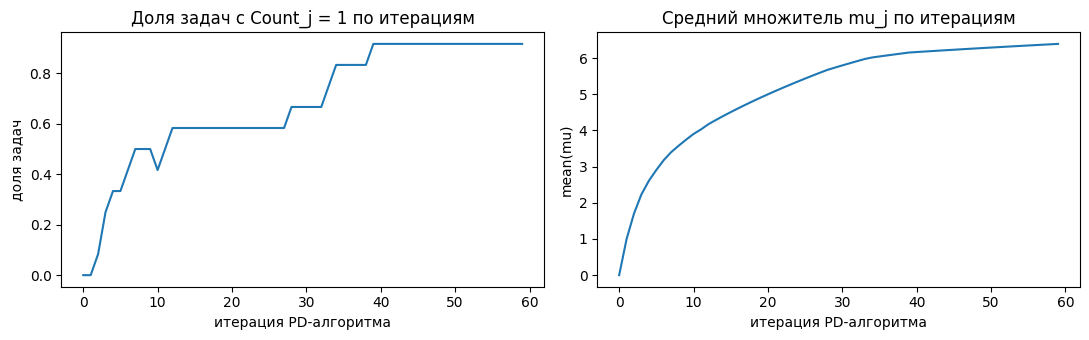

In [5]:
fraction_tight = [np.mean(s.count == 1) for s in trace]
mean_mu = [s.mu.mean() for s in trace]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(fraction_tight)
axes[0].set_title("Доля задач с Count_j = 1 по итерациям")
axes[0].set_xlabel("итерация PD-алгоритма")
axes[0].set_ylabel("доля задач")

axes[1].plot(mean_mu)
axes[1].set_title("Средний множитель mu_j по итерациям")
axes[1].set_xlabel("итерация PD-алгоритма")
axes[1].set_ylabel("mean(mu)")
plt.tight_layout()
plt.show()


## 4. Сборка NAR-сэмпла (вход + трасса + метка), как ожидает PDNAR

`build_gap_sample` пакует всё в формат "state trace" $\{S^{(t)}\}_{t=0}^{T}$ из статьи
(раздел 3.1): вход (cost/resource/capacity/compatible), трасса классического алгоритма
(mu, x, count, remaining_capacity по шагам) и целевая метка `y_assignment` — точное решение
для малых инстансов (`EXACT_LABEL_TASK_LIMIT = 14`, у нас как раз 12 задач, поэтому метка
`exact`), либо PD+regret-эвристика для крупных.


In [6]:
sample = build_gap_sample(n_agents=instance.n_agents, n_tasks=instance.n_tasks, seed=1)
print("Источник метки (label):", sample["y_source"])
print("Целевая стоимость (y_objective):", round(sample["y_objective"], 3))
print("Форма трассы: mu", sample["trace"]["mu"].shape,
      "| x", sample["trace"]["x"].shape,
      "| count", sample["trace"]["count"].shape,
      "| remaining_capacity", sample["trace"]["remaining_capacity"].shape)


Источник метки (label): exact
Целевая стоимость (y_objective): 73.279
Форма трассы: mu (60, 12) | x (60, 5, 12) | count (60, 12) | remaining_capacity (60, 5)


## 5. PDNAR: bipartite граф + GNN (Encoder → Processor → Decoder)

Как на слайдах со схемой bipartite-графа (`agent`↔`task`, primal/dual переменные):
- **dual-узлы** = задачи $j$ (несут $\mu_j$, $\text{Count}_j$);
- **primal-узлы** = агенты $i$ (несут $b_i$, остаток ёмкости);
- **рёбра** $(i,j)$ = допустимые назначения, с признаками $c_{ij}$, $a_{ij}$, $c_{ij}-\mu_j$.

Декодер читает предсказание $\hat\mu_j$ и логит $x_{ij}$ для каждого ребра.

Эта часть требует `torch` + `torch_geometric` — окружение `pdnar` из `environment.yml`
репозитория. Ячейка ниже сама проверяет их наличие и либо строит граф/модель, либо
объясняет, что установить.


In [7]:
from src.model.gap_bipartite import _TORCH_AVAILABLE, gap_sample_to_hetero_data

print("torch / torch_geometric доступны:", _TORCH_AVAILABLE)

if _TORCH_AVAILABLE:
    import torch
    from src.model.gap_bipartite import GAPPDNARModel

    hetero = gap_sample_to_hetero_data(sample, step=0)  # step=0: агент видит "сырой" инстанс
    print(hetero)

    model = GAPPDNARModel(hidden_dim=64, n_steps=8, eps=False)
    with torch.no_grad():
        out = model(hetero)
    print({k: tuple(v.shape) for k, v in out.items()})
else:
    print(
        "Установите зависимости из environment.yml (conda env create -f environment.yml; "
        "conda activate pdnar), затем перезапустите ядро ноутбука — эта и следующая "
        "ячейки построят bipartite-граф и прогонят GAPPDNARModel по-настоящему."
    )


torch / torch_geometric доступны: False
Установите зависимости из environment.yml (conda env create -f environment.yml; conda activate pdnar), затем перезапустите ядро ноутбука — эта и следующая ячейки построят bipartite-граф и прогонят GAPPDNARModel по-настоящему.


## 6. Короткое обучение на мини-датасете и сравнение с точным решением

Обучаем `GAPPDNARModel` предсказывать финальное назначение `y_final` по рёбрам
(бинарная кросс-энтропия на логитах $x_{ij}$) на небольшом наборе случайных GAP-инстансов
(`build_gap_dataset`, в духе "Size and OOD generalization" из статьи), затем прогоняем
на нашем показательном инстансе, восстанавливаем допустимое назначение из предсказанных
вероятностей жадной вставкой (по убыванию $P(x_{ij}=1)$, с проверкой ёмкости) и сравниваем
итоговую стоимость с точным решением и с классическим PD-алгоритмом из части 3.


In [8]:
def assignment_from_edge_scores(instance, ii, jj, scores):
    """Жадно назначает задачи агентам по убыванию предсказанного скора ребра,
    пропуская пары, которые уже не проходят по остатку ёмкости (аналог 'Iterative
    Repair' со слайдов, но по выходу модели, а не по costs)."""
    remaining_capacity = instance.capacity.copy()
    order = np.argsort(-scores)
    assignment = {}
    for idx in order:
        i, j = int(ii[idx]), int(jj[idx])
        if j in assignment:
            continue
        if instance.resource[i, j] <= remaining_capacity[i] + 1e-9:
            assignment[j] = i
            remaining_capacity[i] -= instance.resource[i, j]
    objective = sum(instance.cost[i, j] for j, i in assignment.items())
    return assignment, objective


if _TORCH_AVAILABLE:
    import torch
    import torch.nn as nn

    torch.manual_seed(0)
    train_samples = build_gap_dataset(n_instances=40, n_agents_range=(4, 6), n_tasks_range=(8, 14), seed0=100)
    train_graphs = [gap_sample_to_hetero_data(s, step=0) for s in train_samples]

    model = GAPPDNARModel(hidden_dim=64, n_steps=8, eps=False)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    bce = nn.BCEWithLogitsLoss()

    n_epochs = 30
    losses = []
    for epoch in range(n_epochs):
        epoch_loss = 0.0
        for g in train_graphs:
            optimizer.zero_grad()
            out = model(g)
            target = g["agent", "candidate", "task"].y_final
            loss = bce(out["x_logits_final"], target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_graphs))
        if epoch % 5 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:3d}  BCE loss = {losses[-1]:.4f}")

    plt.figure(figsize=(5, 3))
    plt.plot(losses)
    plt.xlabel("эпоха")
    plt.ylabel("средний BCE loss по датасету")
    plt.title("Обучение GAPPDNARModel на мини-датасете")
    plt.tight_layout()
    plt.show()

    # Инференс на нашем показательном инстансе
    eval_graph = gap_sample_to_hetero_data(sample, step=0)
    with torch.no_grad():
        out = model(eval_graph)
    probs = torch.sigmoid(out["x_logits_final"]).cpu().numpy()
    ii, jj = np.nonzero(instance.compatible)
    gnn_assign, gnn_obj = assignment_from_edge_scores(instance, ii, jj, probs)

    summary = pd.DataFrame(
        [
            ["Точный оптимум (B&B)", exact_obj, instance.n_tasks],
            ["Классический PD + regret-2", r_obj, len(r_assign)],
            ["PDNAR (GAPPDNARModel, 30 эпох)", gnn_obj, len(gnn_assign)],
        ],
        columns=["Метод", "Стоимость", "Покрыто задач"],
    )
    summary["Зазор к оптимуму, %"] = (summary["Стоимость"] - exact_obj) / exact_obj * 100
    print(summary.to_string(index=False))
else:
    print("Пропущено: нужны torch/torch_geometric (см. предыдущую ячейку).")


Пропущено: нужны torch/torch_geometric (см. предыдущую ячейку).


## Итоги

- **Классический primal-dual** (часть 3) — рабочий, полностью проверенный в этом
  окружении Лагранжев алгоритм из `gap_pd.py`: на показательном инстансе (5 агентов,
  12 задач) даёт решение с зазором в единицы процентов от точного оптимума и полным
  покрытием задач после regret-2 repair.
- **PDNAR GNN** (части 5–6) — reference-реализация из `gap_bipartite.py`, повторяющая
  архитектуру Encoder/Processor/Decoder статьи на bipartite agent↔task графе; запускается
  и обучается в окружении `pdnar` (`environment.yml`) на мини-датасете таких же
  синтетических GAP-инстансов, а затем сравнивается с точным решением и с классическим
  алгоритмом на одном и том же показательном примере.
- Для честного сравнения с бумагой не хватает: (а) настоящего hint-supervision по шагам
  трассы (сейчас обучение идёт только на финальной метке `y_final`), (б) integration в
  `main.py`/Hydra/`VCEPLightning`, как у vertex_cover/set_cover/hitting_set — `gap_bipartite.py`
  явно задуман как самостоятельный reference, а не drop-in замена.
